# Machine Learning Model Comparison

This notebook compares three baseline classification models for predicting whether an ETF's 5-trading-day future return is positive. It uses the leakage-safe ML dataset and purged chronological split. It does not write predictions to the database and does not save production model files.

## 1. Setup

Load shared dataset and training utilities from the backend. The database connection uses existing environment-based configuration.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import roc_curve
from sqlalchemy import create_engine

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "backend").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

BACKEND_ROOT = PROJECT_ROOT / "backend"
if str(BACKEND_ROOT) not in sys.path:
    sys.path.insert(0, str(BACKEND_ROOT))

from app.core.config import settings
from app.ml.features import (
    FEATURE_COLUMNS,
    build_ml_dataset,
    load_ml_source_data,
    purged_chronological_split,
    validate_purged_split,
)
from app.ml.training import (
    compare_models,
    evaluate_model,
    evaluate_models_per_etf,
    feature_importance_mapping,
    majority_baseline_accuracy,
    predict_positive_probability,
    train_models,
)

plt.style.use("default")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

engine = create_engine(settings.database_url, pool_pre_ping=True)
FEATURE_COLUMNS

['daily_return',
 'volume_change',
 'close_to_sma20',
 'close_to_sma50',
 'rsi_14',
 'macd',
 'macd_signal',
 'volatility_20',
 'macd_histogram']

## 2. Load Leakage-Safe ML Dataset

The target is `1` when the ETF's 5-trading-day future return is positive, and `0` otherwise. Features use only information available at time `t`; future return and target are not used as features.

In [2]:
source_df = load_ml_source_data(engine)
ml_df = build_ml_dataset(source_df, horizon_days=5)
print("source shape:", source_df.shape)
print("ML dataset shape:", ml_df.shape)
ml_df.head()

source shape: (5572, 10)
ML dataset shape: (5302, 14)


,symbol,date,daily_return,volume_change,close_to_sma20,close_to_sma50,rsi_14,macd,macd_signal,volatility_20,macd_histogram,future_return_5d,target,target_date
0,E1VFVN30,2022-03-21,0.011200,-0.316536,-0.000751,-0.009226,44.244604,-0.208241,-0.196381,0.146541,-0.011860,-0.005934,0,2022-03-28
1,E1VFVN30,2022-03-22,0.005142,9.111700,0.005361,-0.003514,50.184502,-0.167913,-0.190687,0.148213,0.022774,-0.010626,0,2022-03-29
2,E1VFVN30,2022-03-23,-0.005510,-0.844213,0.000832,-0.008444,42.023346,-0.145571,-0.181664,0.148537,0.036093,-0.004749,0,2022-03-30
3,E1VFVN30,2022-03-24,-0.004749,-0.896020,-0.003428,-0.012634,39.700375,-0.135981,-0.172527,0.140243,0.036546,0.005964,1,2022-03-31
4,E1VFVN30,2022-03-25,0.001193,11.010782,-0.001606,-0.010935,41.923077,-0.124524,-0.162927,0.139439,0.038402,0.027800,1,2022-04-01


## 3. Apply Purged Chronological Split

A random split is not appropriate for financial time-series data because it can train on observations that occur after test observations. Since the label uses a 5-trading-day future return, rows immediately before the test period are purged if their target horizon reaches into the test period. This keeps the test set untouched.

In [3]:
unique_dates = pd.Series(sorted(ml_df["date"].unique()))
cutoff_index = int(len(unique_dates) * 0.8)
test_start_date = unique_dates.iloc[cutoff_index]

train_df, test_df, purged_df = purged_chronological_split(
    ml_df,
    test_start_date=test_start_date,
    horizon=5,
)
validate_purged_split(train_df, test_df, test_start_date=test_start_date)

split_summary = pd.DataFrame(
    [
        {"split": "train", "rows": len(train_df), "min_date": train_df["date"].min(), "max_date": train_df["date"].max()},
        {"split": "purged", "rows": len(purged_df), "min_date": purged_df["date"].min(), "max_date": purged_df["date"].max()},
        {"split": "test", "rows": len(test_df), "min_date": test_df["date"].min(), "max_date": test_df["date"].max()},
    ]
)

print("test_start_date:", test_start_date)
split_summary

test_start_date: 2025-09-29 00:00:00


,split,rows,min_date,max_date
0,train,4177,2022-03-21,2025-09-19
1,purged,25,2025-09-22,2025-09-26
2,test,1100,2025-09-29,2026-08-14


## 4. Train/Test Distributions

Check class distributions before modeling. Direction prediction is difficult in financial data, so class balance and baseline performance must be visible.

In [4]:
train_distribution = train_df["target"].value_counts().sort_index().rename_axis("target").reset_index(name="train_rows")
test_distribution = test_df["target"].value_counts().sort_index().rename_axis("target").reset_index(name="test_rows")

display(train_distribution)
display(test_distribution)
display(train_df.groupby("symbol").size().reset_index(name="train_rows"))
display(test_df.groupby("symbol").size().reset_index(name="test_rows"))

,target,train_rows
0,0,1811
1,1,2366


,target,test_rows
0,0,580
1,1,520


,symbol,train_rows
0,E1VFVN30,871
1,FUEDCMID,693
2,FUESSVFL,871
3,FUEVFVND,871
4,FUEVN100,871


,symbol,test_rows
0,E1VFVN30,220
1,FUEDCMID,220
2,FUESSVFL,220
3,FUEVFVND,220
4,FUEVN100,220


## 5. Majority-Class Baseline

A baseline is necessary because a model can look acceptable by accuracy alone when one class is more common. The majority-class baseline predicts the most frequent class in the test set for every test row. Models should be compared against this simple benchmark and evaluated using balanced accuracy, F1, and ROC-AUC as well.

In [5]:
baseline = majority_baseline_accuracy(train_df, test_df)
print(f"Majority class in test set: {baseline.majority_class}")
print(f"Majority-class baseline accuracy: {baseline.majority_baseline_accuracy:.4f}")

Majority class in test set: 0
Majority-class baseline accuracy: 0.5273


## 6. Train Logistic Regression, Random Forest, and XGBoost

The Logistic Regression model uses a `StandardScaler` fitted only on the training data. Tree-based models are trained without scaling. No model is saved here.

In [6]:
models = train_models(train_df, random_state=42)
list(models.keys())

['Logistic Regression', 'Random Forest', 'XGBoost']

## 7. Comparison Metrics Table

Evaluate on the untouched test set. The table is sorted by ROC-AUC for readability, but the final model choice should also consider balanced accuracy, F1-score, ETF-level stability, explainability, and simplicity.

In [7]:
comparison = compare_models(models, test_df)
comparison

,model,accuracy,balanced_accuracy,precision,recall,f1,roc_auc,confusion_matrix
0,Logistic Regression,0.4727,0.4942,0.4695,0.8885,0.6144,0.4969,"[[58, 522], [58, 462]]"
1,XGBoost,0.4691,0.4870,0.4649,0.8154,0.5922,0.4884,"[[92, 488], [96, 424]]"
2,Random Forest,0.4691,0.4920,0.4684,0.9115,0.6188,0.4721,"[[42, 538], [46, 474]]"


## 8. Confusion Matrices

Confusion matrices show the types of classification mistakes each model makes.

/var/folders/p7/llsccrr56ls1pp2132n0jfxw0000gp/T/ipykernel_19139/451237921.py:14: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


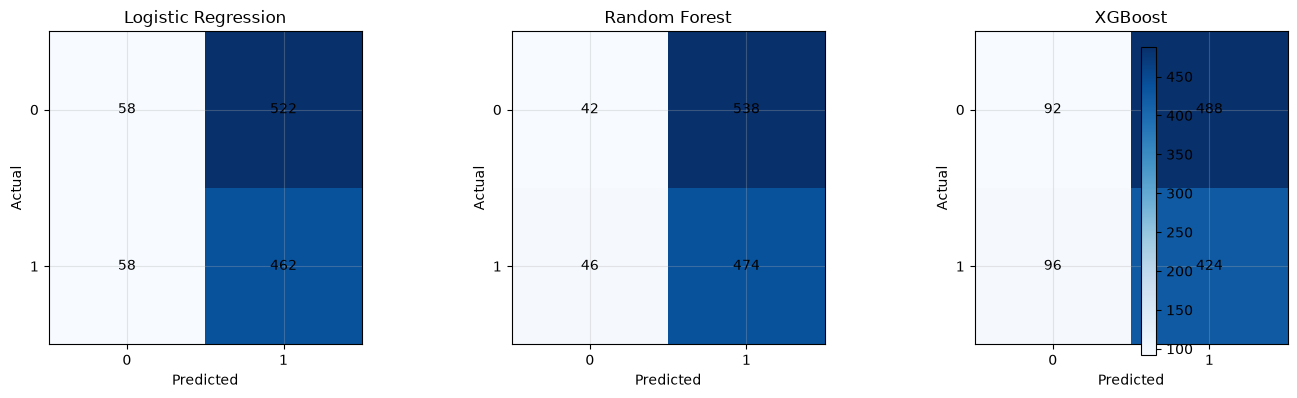

In [8]:
fig, axes = plt.subplots(1, len(models), figsize=(14, 4))
for ax, (model_name, model) in zip(axes, models.items()):
    matrix = np.array(evaluate_model(model_name, model, test_df).confusion_matrix)
    image = ax.imshow(matrix, cmap="Blues")
    ax.set_title(model_name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    for row in range(2):
        for col in range(2):
            ax.text(col, row, matrix[row, col], ha="center", va="center")
fig.colorbar(image, ax=axes, fraction=0.02, pad=0.04)
plt.tight_layout()
plt.show()

## 9. ROC Curves

ROC curves compare each model's ability to rank positive examples above negative examples across thresholds. Thresholds are not tuned in this notebook.

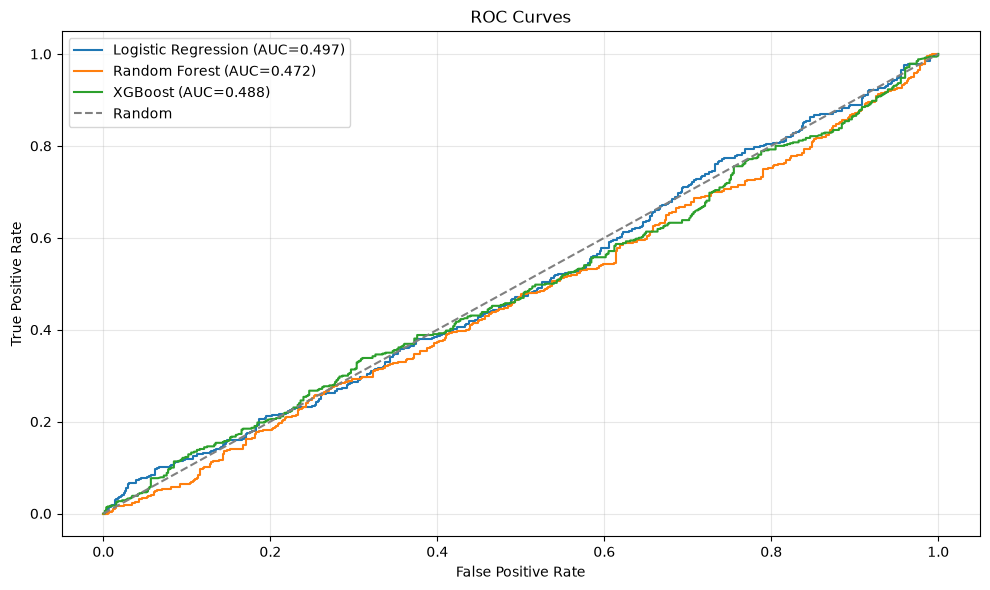

In [9]:
fig, ax = plt.subplots()
for model_name, model in models.items():
    probabilities = predict_positive_probability(model, test_df)
    fpr, tpr, _ = roc_curve(test_df["target"], probabilities)
    roc_auc = comparison.loc[comparison["model"] == model_name, "roc_auc"].iloc[0]
    ax.plot(fpr, tpr, label=f"{model_name} (AUC={roc_auc:.3f})")
ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random")
ax.set_title("ROC Curves")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.legend()
plt.tight_layout()
plt.show()

## 10. Per-ETF Performance

Evaluate the same global models separately by ETF. This helps identify whether performance is consistent or concentrated in only one ETF.

In [10]:
per_etf_metrics = evaluate_models_per_etf(models, test_df)
per_etf_metrics

,symbol,model,accuracy,f1
0,E1VFVN30,Logistic Regression,0.5500,0.6526
1,E1VFVN30,Random Forest,0.4727,0.6398
2,E1VFVN30,XGBoost,0.4727,0.6027
3,FUEDCMID,Logistic Regression,0.4136,0.5686
4,FUEDCMID,Random Forest,0.4318,0.5763
5,FUEDCMID,XGBoost,0.4500,0.5842
6,FUESSVFL,Logistic Regression,0.4682,0.6034
7,FUESSVFL,Random Forest,0.4545,0.5683
8,FUESSVFL,XGBoost,0.4545,0.5420
9,FUEVFVND,Logistic Regression,0.4182,0.5733


## 11. Feature Importance and Coefficients

For Random Forest and XGBoost, report built-in feature importances. For Logistic Regression, report coefficients after scaling. SHAP is intentionally not used at this stage.

In [11]:
for model_name, model in models.items():
    print(model_name)
    display(feature_importance_mapping(model_name, model))

Logistic Regression


,feature,coefficient
0,close_to_sma20,-0.678528
1,close_to_sma50,0.564234
2,macd_histogram,0.285743
3,macd_signal,-0.134222
4,rsi_14,0.106117
5,volume_change,0.068953
6,macd,-0.051547
7,volatility_20,-0.040065
8,daily_return,0.032516


Random Forest


,feature,importance
0,close_to_sma50,0.190211
1,volatility_20,0.161929
2,macd_signal,0.110835
3,macd,0.107100
4,close_to_sma20,0.103555
5,macd_histogram,0.098833
6,rsi_14,0.098527
7,daily_return,0.090758
8,volume_change,0.038253


XGBoost


,feature,importance
0,close_to_sma50,0.138703
1,macd_signal,0.134752
2,volatility_20,0.130207
3,close_to_sma20,0.124002
4,macd,0.122073
5,macd_histogram,0.116318
6,rsi_14,0.107243
7,daily_return,0.068013
8,volume_change,0.058688


## 12. Discussion

Financial direction prediction is difficult because prices are noisy, regimes change, and technical indicators describe recent behavior rather than guaranteeing future returns. A preferred model should not be chosen by accuracy alone. Consider ROC-AUC, balanced accuracy, F1-score, consistency across ETFs, explainability, and implementation simplicity. If all models perform weakly relative to the majority-class baseline, that result should be reported honestly rather than hidden.